# 04 — Evaluation & Error Analysis
**Owners: Jamie + Fuad | Status: Uses trained artifacts from notebook 02**

## What this notebook does
- **Replicates notebook 02 preprocessing** on train/test (`cleaned_text`) then **transforms with the saved TF–IDF** (`data/models/tfidf.pkl`) — same pipeline as training, no refit.
- **Global test metrics (same as 02):** macro / micro / samples F1 and macro ROC-AUC (OvR) for NB vs LogReg.
- **Per-emotion F1:** side-by-side bar chart (NB vs LogReg).
- **LogReg learning curves:** macro-F1 vs training set size (subset of train for runtime; fixed random seed).
- **Error analysis:** 25 test posts with at least one wrong label (LogReg), sorted by harm, tagged with simple patterns (short text, negation, multi-label ambiguity, possible sarcasm).
- **Torture test:** 10 hand-crafted sentences — expected mini-labels vs NB / LogReg predictions.
- **Interpretability:** top positive TF–IDF features per emotion from LogReg coefficients (OvR).

## Prerequisites
Run `notebooks/02_classifiers.ipynb` first (or ensure `data/models/*.pkl` exist).

## Input files
- `data/processed/train.csv`, `data/processed/test.csv`
- `data/models/tfidf.pkl`, `data/models/nb_model.pkl`, `data/models/lr_model.pkl`

## How to run
From repo root, open this notebook under `notebooks/`. Run cells top to bottom.

In [1]:
# --- paths & same preprocessing as 02_classifiers ---
from pathlib import Path

import joblib
import json
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import nltk
from better_profanity import profanity
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

ROOT = Path("..")
PROCESSED_DIR = ROOT / "data" / "processed"
MODELS_DIR = ROOT / "data" / "models"

nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()
profanity.load_censor_words()


def preprocess_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = text.split()
    tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
        if token not in stop_words and len(token) > 2
    ]
    return " ".join(tokens)


train_df = pd.read_csv(PROCESSED_DIR / "train.csv")
test_df = pd.read_csv(PROCESSED_DIR / "test.csv")
for df in (train_df, test_df):
    df["cleaned_text"] = df["text"].apply(preprocess_text)

label_cols = [c for c in train_df.columns if c not in ("text", "cleaned_text")]
label_cols_path = MODELS_DIR / "label_cols.json"
if label_cols_path.is_file():
    with open(label_cols_path, encoding="utf-8") as f:
        label_cols_file = json.load(f)
    assert label_cols == label_cols_file, "label order mismatch vs label_cols.json"


def labels_str(vec) -> str:
    return "[" + ", ".join(label_cols[i] for i, v in enumerate(vec) if v) + "]"


tfidf = joblib.load(MODELS_DIR / "tfidf.pkl")
nb_clf = joblib.load(MODELS_DIR / "nb_model.pkl")
lr_clf = joblib.load(MODELS_DIR / "lr_model.pkl")

X_train = tfidf.transform(train_df["cleaned_text"])
X_test = tfidf.transform(test_df["cleaned_text"])
y_train = train_df[label_cols].to_numpy()
y_test = test_df[label_cols].to_numpy()

y_pred_nb = nb_clf.predict(X_test)
y_pred_lr = lr_clf.predict(X_test)
y_prob_nb = nb_clf.predict_proba(X_test)
y_prob_lr = lr_clf.predict_proba(X_test)

print(f"Labels ({len(label_cols)}): {label_cols}")
print(f"X_train {X_train.shape} | X_test {X_test.shape} | y_test {y_test.shape}")


Labels (7): ['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise', 'neutral']
X_train (43410, 5000) | X_test (5427, 5000) | y_test (5427, 7)


In [2]:
# --- Global test metrics (definitions match notebook 02) ---
from sklearn.metrics import f1_score, roc_auc_score


def f1_bundle(y_true, y_pred):
    return {
        "macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "micro": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "samples": f1_score(y_true, y_pred, average="samples", zero_division=0),
    }


nb_f1 = f1_bundle(y_test, y_pred_nb)
lr_f1 = f1_bundle(y_test, y_pred_lr)
nb_auc = roc_auc_score(y_test, y_prob_nb, average="macro", multi_class="ovr")
lr_auc = roc_auc_score(y_test, y_prob_lr, average="macro", multi_class="ovr")

print("=== Test set — NB vs LogReg ===\n")
print(f"{'':14} {'NB':>10} {'LogReg':>10}")
for key, title in [("macro", "Macro-F1"), ("micro", "Micro-F1"), ("samples", "Samples-F1")]:
    print(f"{title:14} {nb_f1[key]:>10.4f} {lr_f1[key]:>10.4f}")
print(f"{'ROC-AUC (OvR)':14} {nb_auc:>10.4f} {lr_auc:>10.4f}")


=== Test set — NB vs LogReg ===

                       NB     LogReg
Macro-F1           0.2472     0.4893
Micro-F1           0.4402     0.5758
Samples-F1         0.3268     0.6058
ROC-AUC (OvR)      0.7505     0.8384


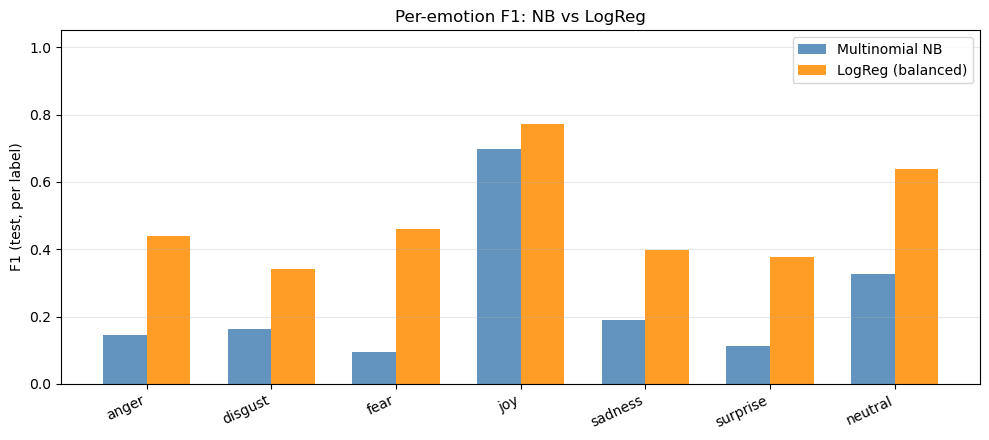

In [3]:
# --- Per-emotion F1 (test): NB vs LogReg bar chart ---
f1_nb_per = f1_score(y_test, y_pred_nb, average=None, zero_division=0)
f1_lr_per = f1_score(y_test, y_pred_lr, average=None, zero_division=0)

x = np.arange(len(label_cols))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(x - width / 2, f1_nb_per, width, label="Multinomial NB", color="steelblue", alpha=0.85)
ax.bar(x + width / 2, f1_lr_per, width, label="LogReg (balanced)", color="darkorange", alpha=0.85)
ax.set_xticks(x, label_cols, rotation=25, ha="right")
ax.set_ylabel("F1 (test, per label)")
ax.set_title("Per-emotion F1: NB vs LogReg")
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


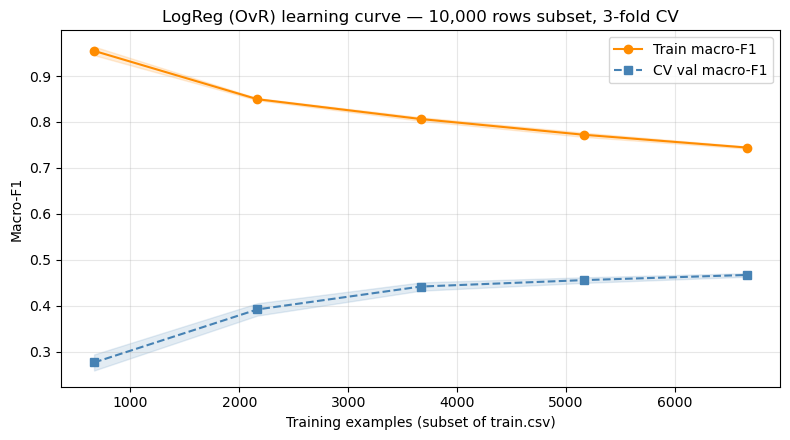

In [4]:
# --- LogReg learning curves (macro-F1) ---
# Subsample training data for speed; same hyperparameters as notebook 02.
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import learning_curve
from sklearn.multiclass import OneVsRestClassifier

LC_SEED = 42
N_LC = min(10_000, X_train.shape[0])
rng = np.random.RandomState(LC_SEED)
idx = rng.choice(X_train.shape[0], size=N_LC, replace=False)
X_lc = X_train[idx]
y_lc = y_train[idx]

lr_pipe = OneVsRestClassifier(
    LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        C=1.0,
        solver="lbfgs",
        random_state=LC_SEED,
    ),
    n_jobs=-1,
)

train_sizes, train_scores, val_scores = learning_curve(
    lr_pipe,
    X_lc,
    y_lc,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=3,
    scoring="f1_macro",
    n_jobs=-1,
    random_state=LC_SEED,
)
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(train_sizes, train_mean, "o-", label="Train macro-F1", color="darkorange")
ax.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15,
    color="darkorange",
)
ax.plot(train_sizes, val_mean, "s--", label="CV val macro-F1", color="steelblue")
ax.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.15,
    color="steelblue",
)
ax.set_xlabel("Training examples (subset of train.csv)")
ax.set_ylabel("Macro-F1")
ax.set_title(f"LogReg (OvR) learning curve — {N_LC:,} rows subset, 3-fold CV")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [5]:
# --- Error analysis: 25 test examples (LogReg) with heuristic tags ---
def failure_pattern_tags(text: str, y_true_row, y_pred_row) -> str:
    tags = []
    lower = text.lower()
    word_count = len(text.split())
    if word_count < 10:
        tags.append("short_text")
    if any(p in lower for p in ("n't", " not ", " never ", " no ", " nobody ", " nothing ")):
        tags.append("negation")
    if int(y_true_row.sum()) >= 3:
        tags.append("multi_label")
    if "?" in text and any(w in lower for w in ("love", "great", "best", "awesome", "fantastic")):
        tags.append("possible_sarcasm")
    if not tags:
        tags.append("other")
    return ", ".join(tags)


hamming = np.mean(np.abs(y_test - y_pred_lr), axis=1)
wrong_ix = np.where((y_test != y_pred_lr).any(axis=1))[0]
wrong_sorted = wrong_ix[np.argsort(-hamming[wrong_ix])][:25]

rows = []
for i in wrong_sorted:
    rows.append(
        {
            "pattern": failure_pattern_tags(test_df.iloc[i]["text"], y_test[i], y_pred_lr[i]),
            "hamming": round(float(hamming[i]), 3),
            "true": labels_str(y_test[i]),
            "pred": labels_str(y_pred_lr[i]),
            "text": test_df.iloc[i]["text"][:200] + ("…" if len(test_df.iloc[i]["text"]) > 200 else ""),
        }
    )

error_df = pd.DataFrame(rows).sort_values(["pattern", "hamming"], ascending=[True, False])
error_df


,pattern,hamming,true,pred,text
3,negation,0.714,[neutral],"[anger, disgust, fear, sadness]","I've had a few blisters from hot welds, but no..."
4,negation,0.714,[joy],"[anger, disgust, fear, sadness]",At least it isn't too terrible? Actually it's ...
10,negation,0.714,[joy],"[anger, sadness, surprise, neutral]",My son isn't old enough to remember his brothe...
11,negation,0.714,"[sadness, surprise]","[anger, disgust, neutral]",Oh hell no. Shes blind!!! No way in HELL is sh...
15,negation,0.571,"[anger, surprise]","[joy, sadness]",What is beautiful about this planet? Nature is...
22,negation,0.571,[joy],"[anger, disgust, sadness]",A best friend would get me a vibrator. Not som...
24,negation,0.571,[joy],"[anger, surprise, neutral]",It isn't incorrect to use 'they' even when a p...
0,other,0.857,[joy],"[anger, disgust, fear, surprise, neutral]",Franchise QB's are leaders who set the tone fo...
2,other,0.714,[sadness],"[anger, disgust, surprise, neutral]","The questions are normal enough, but all at on..."
5,other,0.714,[joy],"[anger, sadness, surprise, neutral]",So true! My brain always goes to these places ...


In [6]:
# --- Torture test: 10 hand-crafted sentences ---
# Expected labels are heuristic "gold" for discussion only (not from the dataset).


def label_vec(**kwargs):
    return np.array([int(kwargs.get(c, 0)) for c in label_cols], dtype=np.int8)


torture_cases = [
    ("I am so angry I could scream — this is unbelievable!", label_vec(anger=1)),
    ("That movie made me sick; absolutely disgusting acting.", label_vec(disgust=1)),
    ("I'm terrified something bad will happen tonight.", label_vec(fear=1)),
    ("Best day ever! I love everyone right now!", label_vec(joy=1)),
    ("I cried myself to sleep after we broke up.", label_vec(sadness=1)),
    ("Wait, you did WHAT? No way!", label_vec(surprise=1)),
    ("The weather is okay. Traffic was normal. Nothing special.", label_vec(neutral=1)),
    ("I'm not angry at all, everything is fine. (clenched teeth)", label_vec(anger=1, neutral=1)),
    ("Short.", label_vec(neutral=1)),
    ("This is the best disaster I've ever seen — flawless failure?", label_vec(joy=1, surprise=1)),
]

texts_torture = [t for t, _ in torture_cases]
y_torture_exp = np.stack([e for _, e in torture_cases])
clean_torture = [preprocess_text(t) for t in texts_torture]
X_torture = tfidf.transform(clean_torture)
pred_nb_t = nb_clf.predict(X_torture)
pred_lr_t = lr_clf.predict(X_torture)

out = []
for i, sentence in enumerate(texts_torture):
    out.append(
        {
            "sentence": sentence,
            "expected": labels_str(y_torture_exp[i]),
            "NB": labels_str(pred_nb_t[i]),
            "LogReg": labels_str(pred_lr_t[i]),
        }
    )
pd.DataFrame(out)


,sentence,expected,NB,LogReg
0,I am so angry I could scream — this is unbelie...,[anger],[],"[anger, fear, surprise]"
1,That movie made me sick; absolutely disgusting...,[disgust],[disgust],"[anger, disgust, sadness]"
2,I'm terrified something bad will happen tonight.,[fear],[fear],"[fear, sadness]"
3,Best day ever! I love everyone right now!,[joy],[joy],[joy]
4,I cried myself to sleep after we broke up.,[sadness],[],"[sadness, neutral]"
5,"Wait, you did WHAT? No way!",[surprise],[],"[surprise, neutral]"
6,The weather is okay. Traffic was normal. Nothi...,[neutral],[],[neutral]
7,"I'm not angry at all, everything is fine. (cle...","[anger, neutral]",[],[anger]
8,Short.,[neutral],[],"[surprise, neutral]"
9,This is the best disaster I've ever seen — fla...,"[joy, surprise]",[],"[disgust, joy, sadness]"


In [7]:
# --- LogReg: top positive TF–IDF features per emotion (OvR coefficients) ---
feature_names = np.array(tfidf.get_feature_names_out())
TOP_K = 12

for j, emotion in enumerate(label_cols):
    coef = lr_clf.estimators_[j].coef_.ravel()
    top = np.argsort(-coef)[:TOP_K]
    print(f"\n{emotion} — top {TOP_K} features by coefficient:")
    print(", ".join(feature_names[top]))



anger — top 12 features by coefficient:
hate, fuck, stupid, fucking, annoying, idiot, asshole, suck, bastard, frustrating, annoyed, disagree

disgust — top 12 features by coefficient:
disgusting, worst, awful, worse, weird, nasty, ugly, disgust, creepy, horrible, terrible, gross

fear — top 12 features by coefficient:
scared, afraid, scary, terrible, worried, horrible, terrifying, fear, scare, nervous, terrified, dangerous

joy — top 12 features by coefficient:
thanks, thank, love, lol, great, hope, glad, awesome, amazing, haha, wish, beautiful

sadness — top 12 features by coefficient:
sorry, sad, sadly, embarrassing, disappointing, awkward, disappointed, hurt, apology, shame, regret, miss

surprise — top 12 features by coefficient:
surprised, curious, confused, wonder, realized, wow, realize, wondering, realization, shocked, curiosity, omg

neutral — top 12 features by coefficient:
remindme, trump, hello, sure dont, status, brick, tea, insert, mavs, including, socialism, stock
